In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmasher as cmr
import matplotlib.colors as clrs
import matplotlib.cm as cmap
import matplotlib.pylab as pylab
from scipy.special import sph_harm
from scipy.integrate import nquad
from scipy.optimize import root
from mpmath import polylog
from scipy.interpolate import interp1d




colors = ['#8a1f1f','#79a43a','#C59D34','#171782', '#cf6717','#ad6faa',
          '#009999','#828282']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)
plt.rcParams['lines.linewidth'] = 3.0
plt.rcParams['axes.linewidth'] = 2.

# Load plot style

from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Tick tweaks 

from matplotlib import ticker

/var/folders/19/gw63c49d5ns7rcfbl2csybn00000gn/T/ipykernel_60590/6035829.py:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


# Here I start to compute the absorption cross section for a variety of elements

This set of subroutines calculates the photoelectric absorption cross sections for the elements H, He, C, N, O, Ne, Na, Mg, Al, Si, S, Cl, A, Ca, Cr, Fe, and Ni.  The result is in $cm^2/g$, given the $\textbf{photon energy in eV}$.  These functions are $\textit{valid only over the energy range 30 - 10,000 eV.}$

I took the functions from https://cdsarc.cds.unistra.fr/ftp/VI/62/.

These functions are relevant when we want to describe the ``phabs" and ``vphabs" models in Xspec.

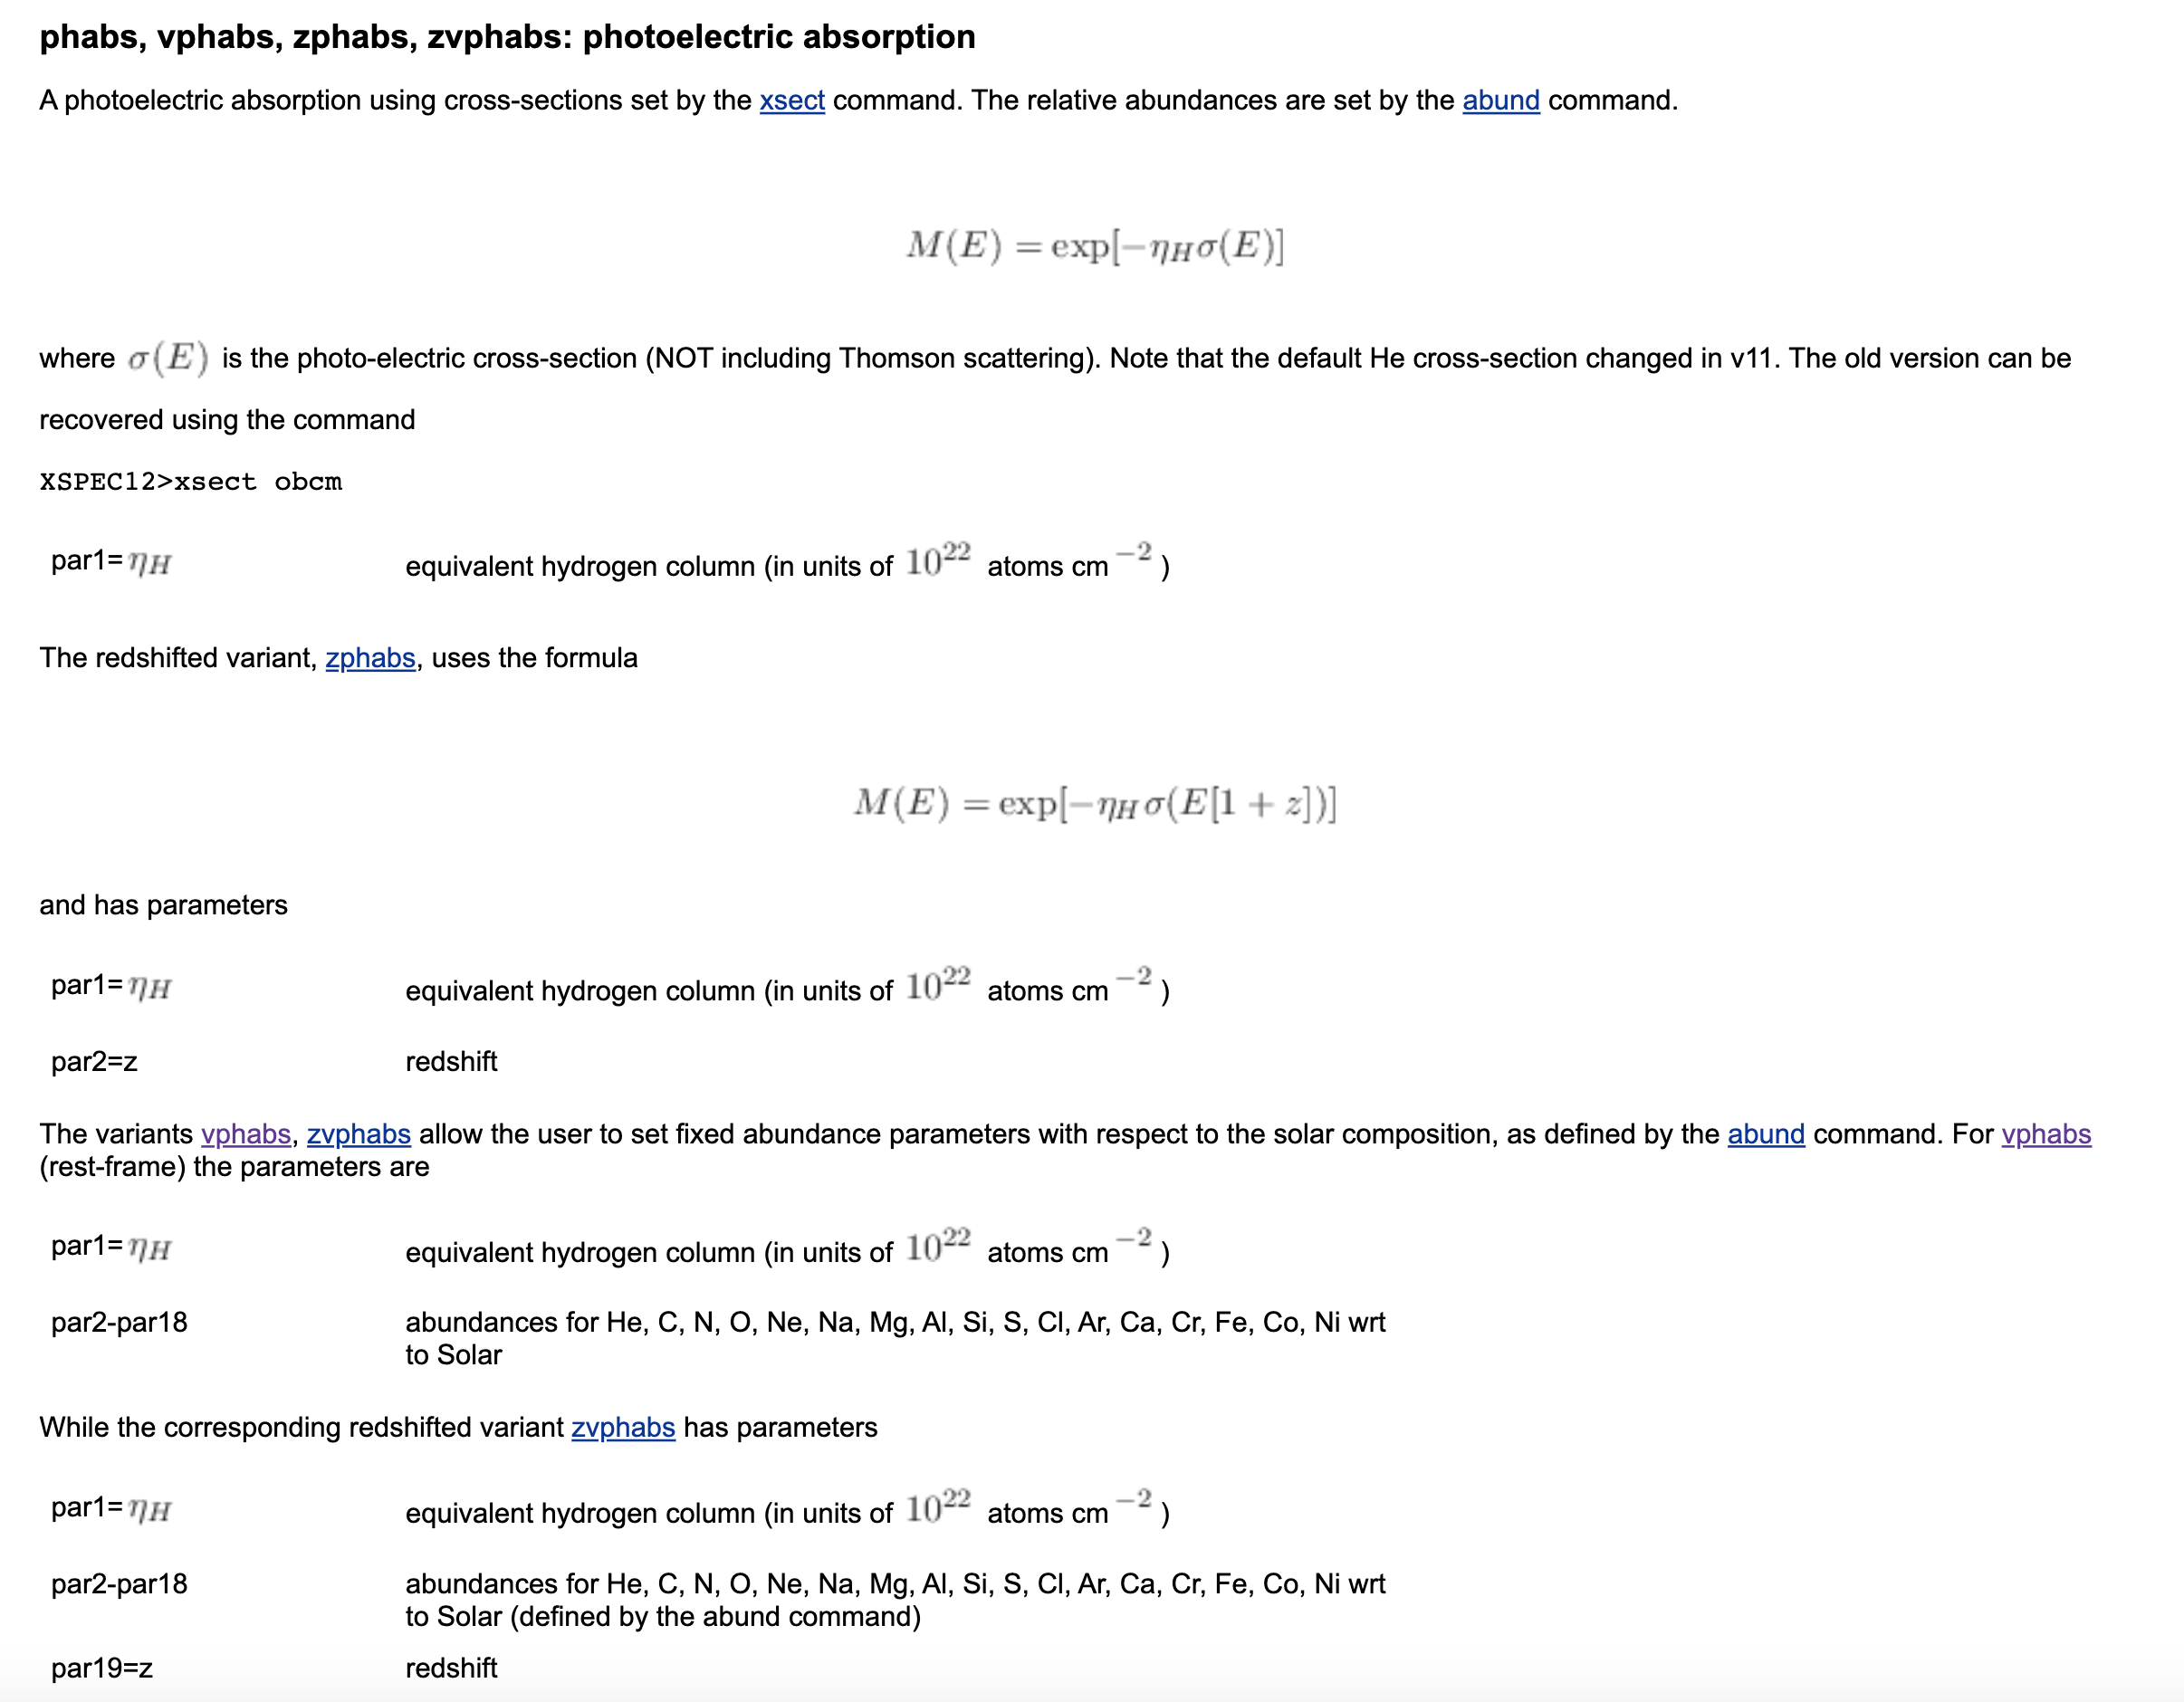


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions for each element

def alum(E):
    Elog = np.log(E)
    X = np.where(E < 72.78, 
                 26.90487 + (3. - 9.135221) * Elog + 1.175546 * Elog**2,
                 np.where(E < 1559.9, 
                          -38.1232 + 29.5161 * Elog - 4.45416 * Elog**2 + 0.226204 * Elog**3,
                          14.6897 + 4.22743 * Elog - 0.344185 * Elog**2 + 8.18542e-3 * Elog**3))
    Alum = np.exp(X) / (E**3)
    return Alum

def argon(E):
    Elog = np.log(E)
    X = np.where(E < 245.0, 
                 -330.3509 + (267.7433 + 3.) * Elog - 78.90498 * Elog**2 + 10.35983 * Elog**3 - 0.5140201 * Elog**4,
                 np.where(E < 3202.9, 
                          -5.71870 + 8.85812 * Elog - 0.307357 * Elog**2 + 0.00169351 * Elog**3 - 0.0138134 * Elog**4 + 0.00120451 * Elog**5,
                          19.1905 + 2.74276 * Elog - 0.164603 * Elog**2 + 0.00165895 * Elog**3))
    Argon = np.exp(X) / (E**3)
    return Argon

def calc(E):
    Elog = np.log(E)
    X = np.where(E < 349.31, 
                 -873.972 + (865.5231 + 3.) * Elog - 339.678 * Elog**2 + 66.83369 * Elog**3 - 6.590398 * Elog**4 + 0.2601044 * Elog**5,
                 np.where(E < 4038.1, 
                          -3449.707 + (2433.409 + 3.) * Elog - 682.0668 * Elog**2 + 95.3563 * Elog**3 - 6.655018 * Elog**4 + 0.1854492 * Elog**5,
                          18.89376 + (3. - 0.2903538) * Elog - 0.1377201 * Elog**2))
    Calc = np.exp(X) / (E**3)
    return Calc

def carbon(E):
    Elog = np.log(E)
    X = np.where(E < 284.0, 
                 8.74161 + 7.13348 * Elog - 1.14604 * Elog**2 + 0.0677044 * Elog**3,
                 3.81334 + 8.93626 * Elog - 1.06905 * Elog**2 + 0.0422195 * Elog**3)
    Carbon = np.exp(X) / (E**3)
    return Carbon

def chlorn(E):
    Elog = np.log(E)
    X = np.where(E < 202.0, 
                 6253.247 + (3. - 8225.248) * Elog + 4491.675 * Elog**2 - 1302.145 * Elog**3 + 211.4881 * Elog**4 - 18.25547 * Elog**5 + 0.6545154 * Elog**6,
                 np.where(E < 2819.6, 
                          -233.0502 + (143.9776 + 3.) * Elog - 31.12463 * Elog**2 + 2.938618 * Elog**3 - 0.104096 * Elog**4,
                          -23.74675 + (14.50997 + 3.) * Elog - 1.857953 * Elog**2 + 0.066208832 * Elog**3))
    Chlorn = np.exp(X) / (E**3)
    return Chlorn

def chrom(E):
    Elog = np.log(E)
    X = np.where(E < 598.0, 
                 -0.4919405 + (12.66939 + 3.) * Elog - 5.199775 * Elog**2 + 1.086566 * Elog**3 - 0.1196001 * Elog**4 + 0.0052152011 * Elog**5,
                 np.where(E < 691.0, 
                          27.29282 + (3. - 2.703336) * Elog,
                          np.where(E < 5988.8, 
                                   -15.2525 + (13.23729 + 3.) * Elog - 1.966778 * Elog**2 + 0.08062207 * Elog**3,
                                   8.307041 + (2.008987 + 3.) * Elog - 0.2580816 * Elog**2)))
    Chrom = np.exp(X) / (E**3)
    return Chrom

def fano(A, B, C, LAMBDA):
    EPS = 911.2671 / LAMBDA
    EPSI = 3.0 - 1.0 / (B * B) + 1.807317
    X = 2.0 * (EPS - EPSI) / C
    Fano = (X - A) * (X - A) / (1.0 + X * X)
    return Fano

def helium(E):
    LAMBDA = 12398.54 / E
    X = np.log10(LAMBDA)
    
    C1 = [-29.53607, 7.083061, 0.8678646, -1.221932, 0.04052997, 0.1317109, -0.03265795, 0.002500933]
    C2 = [-24.65188, 4.354679, -3.553024, 5.57304, -5.872938, 3.720797, -1.226919, 0.1576657]
    Q = [2.81, 2.51, 2.45, 2.44]
    NU = [1.61, 2.795, 3.817, 4.824]
    GAMMA = [0.00264061, 0.000620116, 0.000256061, 0.0001320159]

    Y = np.zeros_like(E)
    
    mask_high = LAMBDA > 503.97
    mask_low = LAMBDA < 46.0
    mask_mid = ~mask_high & ~mask_low
    
    Y[mask_high] = 0.0
    Y[mask_low] = sum(C2[i] * X[mask_low]**i for i in range(8))
    
    Y_mid = sum(C1[i] * X[mask_mid]**i for i in range(8))
    for i in range(4):
        Y_mid += np.log10(fano(Q[i], NU[i], GAMMA[i], LAMBDA[mask_mid]))
    Y[mask_mid] = Y_mid

    SIGMA = 10**Y
    AV = 6.022045e23
    AW = 4.0026
    Helium = SIGMA * AV / AW
    return Helium

def hydro(E):
    Elog = np.log(E)
    X = 21.46941 + (3. - 2.060152) * Elog - 0.1492932 * Elog**2 + 0.0054634294 * Elog**3
    Hydro = np.exp(X) / (E**3)
    return Hydro

def iron(E):
    Elog = np.log(E)
    X = np.where(E < 707.4, 
                 -15.07332 + (18.94335 + 3.) * Elog - 4.862457 * Elog**2 + 0.5573765 * Elog**3 - 0.030065542 * Elog**4 + 0.00049834867 * Elog**5,
                 np.where(E < 7111.2, 
                          -253.0979 + (135.4238 + 3.) * Elog - 25.47119 * Elog**2 + 2.08867 * Elog**3 - 0.064264648 * Elog**4,
                          -1.037655 + (4.022304 + 3.) * Elog - 0.3638919 * Elog**2))
    Iron = np.exp(X) / (E**3)
    return Iron

def magnes(E):
    Elog = np.log(E)
    X = np.where(E < 49.45, 
                 7.107172 + (0.7359418 + 3.) * Elog,
                 np.where(E < 1303.4, 
                          -81.32915 + (62.2775 + 3.) * Elog - 15.00826 * Elog**2 + 1.558686 * Elog**3 - 0.061339621 * Elog**4,
                          -9.161526 + (10.07448 + 3.) * Elog - 1.435878 * Elog**2 + 0.052728362 * Elog**3))
    Magnes = np.exp(X) / (E**3)
    return Magnes

def neon(E):
    Elog = np.log(E)
    X = np.where(E < 867.0, 
                 -3.04041 + 13.0071 * Elog - 1.93205 * Elog**2 + 0.0977639 * Elog**3,
                 17.6007 + 3.29278 * Elog - 0.263065 * Elog**2 + 0.0056829 * Elog**3)
    Neon = np.exp(X) / (E**3)
    return Neon

def nickel(E):
    Elog = np.log(E)
    X = np.where(E < 853.6, 
                 -7.919931 + (11.06475 + 3.0) * Elog - 1.935318 * Elog**2 + 0.093929626 * Elog**3,
                 np.where(E < 8331.6, 
                          3.71129 + 8.45098 * Elog - 0.896656 * Elog**2 + 0.0324889 * Elog**3,
                          28.4989 + 0.485797 * Elog))
    Nickel = np.exp(X) / (E**3)
    return Nickel


def nitro(E):
    Elog = np.log(E)
    X = np.where(E < 401.0, 
                 9.24058 + 7.02985 * Elog - 1.08849 * Elog**2 + 0.0611007 * Elog**3,
                 -13.0353 + 15.4851 * Elog - 1.89502 * Elog**2 + 0.0769412 * Elog**3)
    Nitro = np.exp(X) / (E**3)
    return Nitro

def oxygen(E):
    Elog = np.log(E)
    X = np.where(E < 531.7, 
                 2.57264 + 10.9321 * Elog - 1.79383 * Elog**2 + 0.102619 * Elog**3,
                 16.53869 + (0.6428144+3) * Elog - 0.3177744 * Elog**2 + 0.0079471897 * Elog**3)
    Oxygen = np.exp(X) / (E**3)
    return Oxygen

def silicn(E):
    Elog = np.log(E)
    X = np.where(E < 100.6, 
                 -3.066295 + (7.006248 + 3.) * Elog - 0.9627411 * Elog**2,
                 np.where(E < 1840.0, 
                          -182.7217 + (125.061 + 3.) * Elog - 29.47269 * Elog**2 + 3.03284 * Elog**3 - 0.1173096 * Elog**4,
                          -33.39074 + (18.42992 + 3.) * Elog - 2.385117 * Elog**2 + 0.08887583 * Elog**3))
    Silicn = np.exp(X) / (E**3)
    return Silicn

def sodium(E):
    Elog = np.log(E)
    X = np.where(E < 1071.7, 
                 -2737.598 + (2798.704 + 3.) * Elog - 1009.892 * Elog**2 + 87.16455 * Elog**3 + 43.20644 * Elog**4 - 15.27259 * Elog**5 + 2.180531 * Elog**6 - 0.1526546 * Elog**7 + 0.0043137977 * Elog**8,
                 1.534019 + (6.261744 + 3.) * Elog - 0.9914126 * Elog**2 + 0.035278253 * Elog**3)
    Sodium = np.exp(X) / (E**3)
    return Sodium

def sulfur(E):
    Elog = np.log(E)
    X = np.where(E < 165.0, 
                 598.2911 + (3. - 678.2265) * Elog + 308.1133 * Elog**2 - 68.99324 * Elog**3 + 7.62458 * Elog**4 - 0.3335031 * Elog**5,
                 np.where(E < 2470.5, 
                          3994.831 + (3. - 3693.886) * Elog + 1417.287 * Elog**2 - 287.9909 * Elog**3 + 32.70061 * Elog**4 - 1.968987 * Elog**5 + 0.049149349 * Elog**6,
                          -22.49628 + (14.24599 + 3.) * Elog - 1.848444 * Elog**2 + 0.066506132 * Elog**3))
    Sulfur = np.exp(X) / (E**3)
    return Sulfur

In [3]:
# List of elements I considered

elements = {
    'Aluminum': alum,
    'Argon': argon,
    'Calcium': calc,
    'Carbon': carbon,
    'Chlorine': chlorn,
    'Chromium': chrom,
    'Helium': helium,
    'Hydrogen': hydro,
    'Iron': iron,
    'Magnesium': magnes,
    'Neon': neon,
    'Nickel': nickel,
    'Nitrogen': nitro,
    'Oxygen': oxygen,
    'Silicon': silicn,
    'Sodium': sodium,
    'Sulfur': sulfur
}


Some example plots. Results can be compared with https://physics.nist.gov/PhysRefData/XrayMassCoef/tab3.html

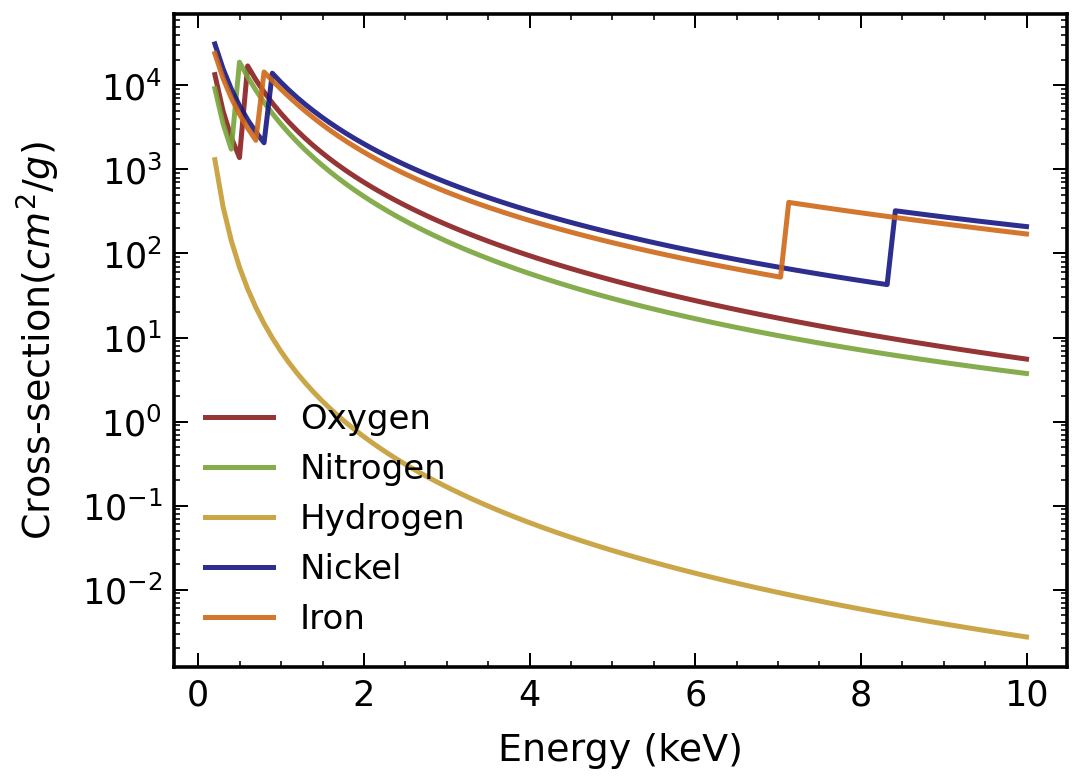

In [169]:
# Example plot
E_ar = np.linspace(0.2 * 1e3, 10 * 1e3, 100)

plt.figure(figsize=(8, 6))
plt.plot(E_ar/1e3, elements['Oxygen'](E_ar), color=colors[0], label ='Oxygen')
plt.plot(E_ar/1e3, elements['Nitrogen'](E_ar), color=colors[1], label ='Nitrogen')
plt.plot(E_ar/1e3, elements['Hydrogen'](E_ar), color=colors[2], label ='Hydrogen')
plt.plot(E_ar/1e3, elements['Nickel'](E_ar), color=colors[3], label ='Nickel')
plt.plot(E_ar/1e3, elements['Iron'](E_ar), color=colors[4], label ='Iron')




plt.xlabel('Energy (keV)')
plt.ylabel(r'$\text{Cross-section} (cm^2/g)$')

plt.yscale('log')

#plt.axis([0.2,10, 1e-3, 4e4])
# K-edge around 1.559 keV

plt.legend()


# Here I can introduce the abundance information

After having defined the absorption cross section in $cm^2/g$, we can then convert them to $cm^2/ H atom$, once we assume some abundance of elements relative to hydrogen. 

In [4]:
# Define the relative abundances based on AG89 for the specified elements. This model is taken from 
#PyAtomdb as pyatomdb.atomdb.get_abundance(abundset='AG89', element=list(range(1, 31)))


abundances_AG89 = {
    1: 1.0, 2: 0.09772372209558111, 3: 1.4454397707459272e-11, 4: 1.4125375446227541e-11,
    5: 3.9810717055349735e-10, 6: 0.0003630780547701018, 7: 0.00011220184543019652,
    8: 0.0008511380382023759, 9: 3.63078054770101e-08, 10: 0.0001230268770812381,
    11: 2.1379620895022326e-06, 12: 3.8018939632056124e-05, 13: 2.9512092266663837e-06,
    14: 3.5481338923357534e-05, 15: 2.818382931264455e-07, 16: 1.62181009735893e-05,
    17: 3.162277660168379e-07, 18: 3.63078054770101e-06, 19: 1.3182567385564074e-07,
    20: 2.2908676527677747e-06, 21: 1.2589254117941675e-09, 22: 9.772372209558112e-08,
    23: 1e-08, 24: 4.677351412871981e-07, 25: 2.4547089156850283e-07, 26: 4.6773514128719816e-05,
    27: 8.317637711026709e-08, 28: 1.778279410038923e-06, 29: 1.62181009735893e-08,
    30: 3.981071705534969e-08
}

# Define the elements and their corresponding Z
element_indices = {
    'H': 1, 'He': 2, 'C': 6, 'N': 7, 'O': 8, 'Ne': 10, 'Na': 11, 'Mg': 12, 'Al': 13, 
    'Si': 14, 'S': 16, 'Cl': 17, 'Ar': 18, 'Ca': 20, 'Cr': 24, 'Fe': 26, 'Ni': 28
}

# Extract abundances for the specified elements
selected_abundances = [abundances_AG89[element_indices[element]] for element in element_indices]

# Convert abundances to log scale
log_abundances = np.log10(selected_abundances)

# Convert log_abundances to a dictionary as specified
abundance_vector = {
    'H': log_abundances[0],
    'He': log_abundances[1],
    'C': log_abundances[2],
    'N': log_abundances[3],
    'O': log_abundances[4],
    'Ne': log_abundances[5],
    'Na': log_abundances[6],
    'Mg': log_abundances[7],
    'Al': log_abundances[8],
    'Si': log_abundances[9],
    'S': log_abundances[10],
    'Cl': log_abundances[11],
    'Ar': log_abundances[12],
    'Ca': log_abundances[13],
    'Cr': log_abundances[14],
    'Fe': log_abundances[15],
    'Ni': log_abundances[16]
}


We can therefore compute the effective cross section taking into account the atomic weights $AW_i$ of each elements and their log abundances $AB_i$

\begin{equation}
\sigma_{\text{eff}}(E) = \sum_{i=1}^{17} \left( \frac{A_i(E) \cdot \text{AW}_i}{N_A} \cdot 10^{\text{AB}_i - \text{AB}_1} \right)
\end{equation}

In [5]:
# Define the atomic weights and Avogadro's number

AW = np.array([1.00797, 4.0026, 12.01115, 14.0067, 15.9994, 20.183,
               22.9898, 24.312, 26.9815, 28.086, 32.064, 35.453,
               39.94, 40.08, 51.996, 55.847, 58.71])
AV = 6.022045e23

def totlxs(E, AB):
    # Mass absorption coefficient functions for the elements
    element_funcs = [
        hydro, helium, carbon, nitro, oxygen, neon, sodium, magnes, alum,
        silicn, sulfur, chlorn, argon, calc, chrom, iron, nickel
    ]
    
    # Calculate mass absorption coefficients for each element
    A = np.array([func(E) for func in element_funcs])
    
    # Calculate the effective cross section
    TOTLXS = np.sum(AW * A / AV * (10**(AB - AB[0])))
    
    return TOTLXS


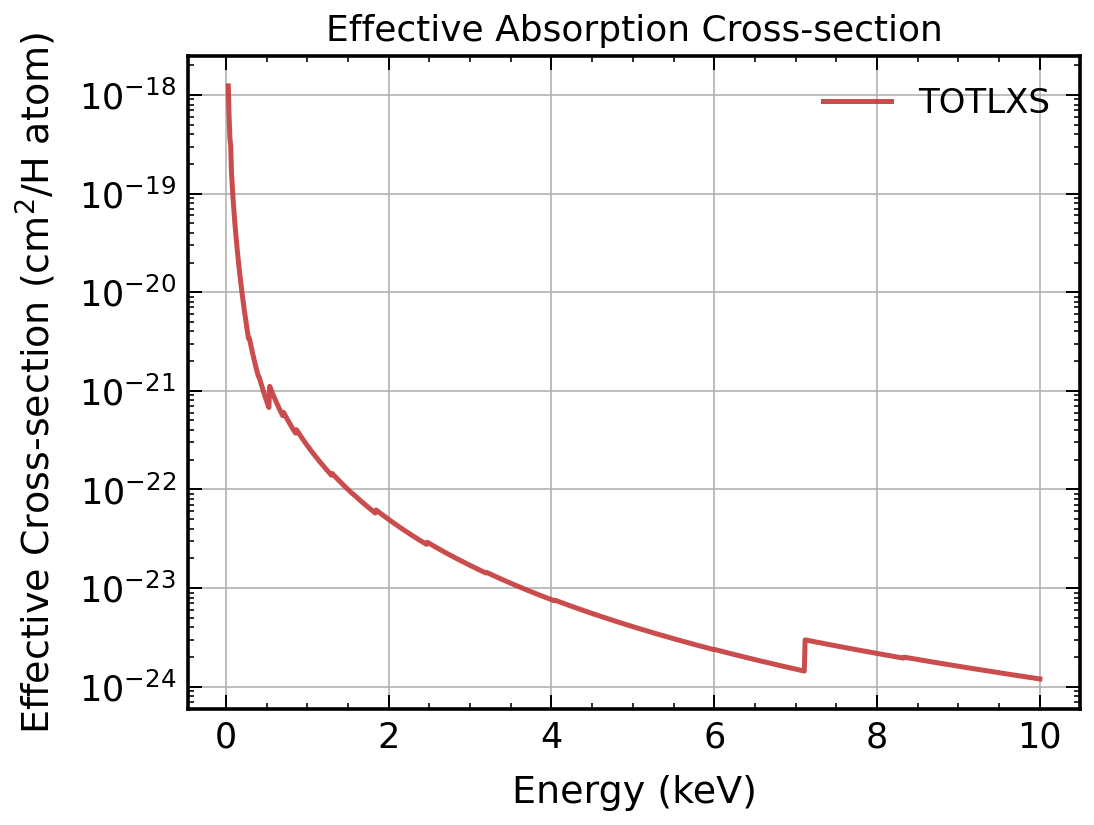

In [7]:
# Convert abundance_vector to a numpy array in the order specified
AB = np.array([
    abundance_vector['H'],
    abundance_vector['He'],
    abundance_vector['C'],
    abundance_vector['N'],
    abundance_vector['O'],
    abundance_vector['Ne'],
    abundance_vector['Na'],
    abundance_vector['Mg'],
    abundance_vector['Al'],
    abundance_vector['Si'],
    abundance_vector['S'],
    abundance_vector['Cl'],
    abundance_vector['Ar'],
    abundance_vector['Ca'],
    abundance_vector['Cr'],
    abundance_vector['Fe'],
    abundance_vector['Ni']
])


E = np.linspace(30, 10000, 1000)  # Energy range in eV

# Calculate TOTLXS for a given energy
TOTLXS_values = np.array([totlxs(e, AB) for e in E])

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(E / 1000, TOTLXS_values, label='TOTLXS')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Effective Cross-section (cm$^2$/H atom)')
plt.title('Effective Absorption Cross-section')
plt.grid(True)
plt.legend()
plt.show()

# Simpler option

This function implements the approximation of Morrison and McCammon (1983) to the interstellar photoelectric absorption cross-section.  Again energy is in eV and the resultant cross-section is in $cm^2/hydrogen atom$.  

Abundances of other elements relative to hydrogen are appropriate for the interstellar medium in the solar neighborhood 

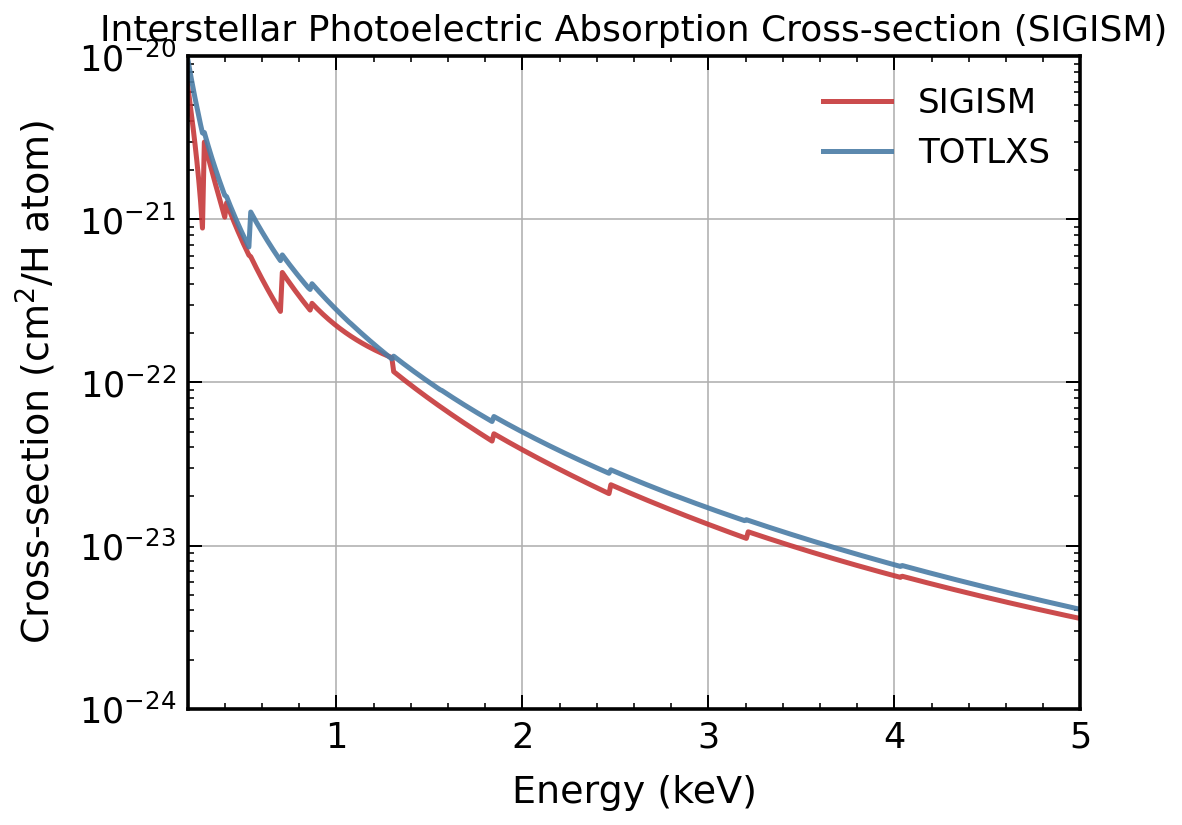

In [8]:
def sigism(ENERGY): # this is the file sigism.for.gz at https://cdsarc.cds.unistra.fr/ftp/VI/62/
    
    # Local constants
    EMAX = np.array([0.100, 0.284, 0.400, 0.532, 0.707, 0.867, 1.303,
                     1.840, 2.471, 3.210, 4.038, 7.111, 8.331, 10.0])
    C0 = np.array([17.3, 34.6, 78.1, 71.4, 95.5, 308.9, 120.6, 141.3,
                   202.7, 342.7, 352.2, 433.9, 629.0, 701.2])
    C1 = np.array([608.1, 267.9, 18.8, 66.8, 145.8, -380.6, 169.3, 
                   146.8, 104.7, 18.7, 18.7, -2.4, 30.9, 25.2])
    C2 = np.array([-2150., -476.1, 4.3, -51.4, -61.1, 294.0, -47.7,
                   -31.5, -17.0, 0.0, 0.0, 0.75, 0.0, 0.0])

    # Convert ENERGY from eV to keV
    E = ENERGY / 1e3

    # Determine the interval in which the energy falls
    i = np.searchsorted(EMAX, E, side='right')
    i = np.clip(i, 1, 14) - 1

    # Calculate the cross-section
    SIGISM = (C0[i] + C1[i] * E + C2[i] * E**2) / E**3 * 1e-24
    return SIGISM

# Example usage and plotting
E = np.linspace(30, 10000, 1000)  # Energy range in eV
SIGISM_values = sigism(E)

plt.figure(figsize=(8, 6))
plt.plot(E / 1000, SIGISM_values, label='SIGISM')
plt.plot(E / 1000, TOTLXS_values, label='TOTLXS')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Cross-section (cm$^2$/H atom)')
plt.title('Interstellar Photoelectric Absorption Cross-section (SIGISM)')
plt.grid(True)
plt.legend()

plt.axis([0.2,5, 1e-24, 1e-20])
plt.show()